# Case-08.2:雙筋梁 + T 形梁設計

依 [ROADMAP.md](../ROADMAP.md) 規劃,延續 Case-08.1 的 `design_rebar()`,
這裡處理單筋矩形梁不夠用的兩種情況:

1. **雙筋梁**:當彎矩需求超過單筋斷面在拉力控制極限下的容量,加壓力
   鋼筋補足
2. **T 形梁**:梁跟樓板整體澆置,受壓翼板寬度遠大於梁寬,要另外處理

**這一課有一個真實踩到的計算 bug,誠實記錄**:雙筋梁設計第一版算出來
的 $\phi M_n$ 比需求少了約 10%,追查後發現是計算 $A_{s2}$(力偶部分
額外拉力鋼筋)那條公式漏除了 $\phi=0.9$——已修正,下面會看到修正
前後的對照。

## 第 1 課:雙筋梁設計——先算單筋能扛多少,不夠才加壓力筋

**設計邏輯**(標準教科書做法,分兩部分疊加):
1. 先算單筋斷面在**拉力控制極限**($\varepsilon_t=0.005$)下能扛的
   彎矩 $M_{u1}$,對應鋼筋量 $A_{s1}$
2. 如果需求 $M_u > M_{u1}$,剩餘的 $M_{u2}=M_u-M_{u1}$ 用一對「壓力
   鋼筋 $A_s'$ + 額外拉力鋼筋 $A_{s2}$」的力偶承擔(兩者對中性軸的
   力矩互相平衡,只提供彎矩,不提供淨壓力)
3. **關鍵檢查點,很多簡化教材會漏掉**:壓力鋼筋不一定真的降伏,要
   用單筋部分算出來的中性軸深度 $c_{max}$ 反推壓力筋位置的應變,
   確認 $\varepsilon_s' \geq \varepsilon_y$ 才能直接假設 $f_s'=f_y$
   ——沒降伏的話要用實際應力 $f_s'=E_s\varepsilon_s'$,鋼筋量要
   放大。

## 環境設置

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
import os
# 永遠重新下載最新版, 不檢查是否已存在——同一個Colab session裡如果先
# 執行過其他notebook, 可能已經有一份舊版rc_design.py殘留在檔案系統,
# "if not exists"這個guard會阻止抓到最新修正(曾經造成ImportError/
# KeyError, 因為抓到的是缺少新函式/新欄位的舊版), 改成無條件重新抓取
!wget -q -O rc_design.py https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py
from rc_design import design_rebar, design_doubly_reinforced, design_Tbeam, draw_rc_section, draw_Tbeam_section

print("rc_design模組已載入: design_rebar, design_doubly_reinforced, design_Tbeam, draw_rc_section, draw_Tbeam_section")

rc_design模組已載入: design_rebar, design_doubly_reinforced, design_Tbeam, draw_rc_section, draw_Tbeam_section


## 第 2 課:設計案例——一根需要雙筋的大彎矩梁

用一根 30×50cm 梁,故意給一個超過單筋極限的大彎矩($M_u=420$
kN-m),逼出雙筋設計的完整流程。

In [3]:
CASE_DR = dict(Mu_kNm=420.0, b_cm=30.0, h_cm=50.0, d_prime_cm=6.0)
r = design_doubly_reinforced(**CASE_DR)

print(f"單筋斷面在拉力控制極限下的容量 Mu1 = {r['Mu1']:.2f} kN-m")
print(f"需求 Mu = {CASE_DR['Mu_kNm']:.2f} kN-m")

if r['need_doubly']:
    print(f"Mu > Mu1, 需要雙筋設計\n")
    print(f"壓力鋼筋位置應變 eps_s' = {r['eps_s_prime']:.5f}")
    if r['compression_yields']:
        print("[PASS] 壓力鋼筋確實降伏, As'=As2")
    else:
        print(f"[注意] 壓力鋼筋未降伏, fs'={r['fs_prime']:.1f}kgf/cm^2, 已放大As'")

    print(f"\nAs1(單筋部分) = {r['As1']:.3f} cm^2")
    print(f"As2(力偶部分, 也是額外拉力鋼筋) = {r['As2']:.3f} cm^2")
    print(f"As總計(拉力鋼筋) = {r['As_total']:.3f} cm^2")
    print(f"As'(壓力鋼筋) = {r['As_prime']:.3f} cm^2")
else:
    print(f"Mu <= Mu1, 單筋斷面就夠了, 不需要雙筋設計")
    print(f"這個案例請改用 design_rebar()(Case-08.1), 不要用這個函式硬做雙筋")

assert r['need_doubly'], f"CASE_DR(Mu={CASE_DR['Mu_kNm']})應該要觸發雙筋設計, 用來示範雙筋流程——若改了b_cm/h_cm導致這裡失敗, 代表也要跟著調高Mu_kNm"
print("\n[PASS] 雙筋設計邏輯正確觸發")


單筋斷面在拉力控制極限下的容量 Mu1 = 273.15 kN-m
需求 Mu = 420.00 kN-m
Mu > Mu1, 需要雙筋設計

壓力鋼筋位置應變 eps_s' = 0.00181
[注意] 壓力鋼筋未降伏, fs'=3613.1kgf/cm^2, 已放大As'

As1(單筋部分) = 21.794 cm^2
As2(力偶部分, 也是額外拉力鋼筋) = 11.577 cm^2
As總計(拉力鋼筋) = 33.371 cm^2
As'(壓力鋼筋) = 13.457 cm^2

[PASS] 雙筋設計邏輯正確觸發


## 第 3 課:交叉驗證——應變相容法(含壓力鋼筋)

跟 08.1 同一套精神,獨立算一次,不只信任公式解本身。**這裡順便留下
第一版 bug 的對照**:第一版 $A_{s2}$ 漏除 $\phi$,算出來的鋼筋量
偏少,用應變相容法驗證時 $\phi M_n$ 只有 377.34 kN-m,跟需求
420 差了 10.16%——正是這個交叉驗證抓到問題的。

In [4]:
def verify_doubly_reinforced(r, b_cm, d_prime_cm, h_cm, fc=280.0, fy=4200.0, Es=2.0e6,
                               beta1=0.85, eps_cu=0.003):
    """獨立應變相容法驗算, 跟rc_design.py內部用的是完全分開的第二套實作
    ——刻意重新寫一次force equilibrium/moment, 不是直接引用r['phiMn_provided']。

    修正記錄: 這格原本固定phi=0.9, 沒有依規範過渡區規則折減——這正是
    後來在rc_design.py本身抓到、也修正過的同一類安全性bug, 這裡的獨立
    驗算函式一直沒有跟著更新, 用巧合的方式(理論連續值As_total, 不是
    真實供給量As_provided)算出接近答案的假象, 掩蓋了真正的問題。這次
    一併對齊: 用真實供給量As_provided、用phi_from_eps_t()動態決定phi、
    用最外層d_t(不是加權形心d)算eps_t。"""
    from rc_design import phi_from_eps_t
    d = r['d']
    d_t = r['d_t']
    As_total = r['As_provided']  # 真實供給量, 不是理論連續值As_total
    As_prime = r['As_prime']

    def section_force(c):
        a = min(beta1*c, h_cm)
        Cc = 0.85*fc*b_cm*a
        eps_y = fy/Es
        eps_s_prime = eps_cu*(c-d_prime_cm)/c if c > 0 else 0
        eps_s_prime = max(min(eps_s_prime, eps_y), -eps_y)
        fs_prime = Es*eps_s_prime
        Cs = As_prime*(fs_prime - 0.85*fc if d_prime_cm <= a else fs_prime)
        eps_s = eps_cu*(c-d)/c if c > 0 else 0
        eps_s = max(min(eps_s, eps_y), -eps_y)
        fs = Es*eps_s
        Ts = As_total*fs
        N = Cc + Cs + Ts
        M = Cc*(d-a/2) + Cs*(d-d_prime_cm)
        return N, M

    c_lo, c_hi = 0.1, h_cm
    for _ in range(100):
        c_mid = (c_lo+c_hi)/2
        N, _ = section_force(c_mid)
        if N > 0: c_hi = c_mid
        else: c_lo = c_mid
    c_final = (c_lo+c_hi)/2
    _, M_final = section_force(c_final)
    Mn_kNm = M_final*9.80665e-5
    eps_t_indep = eps_cu*(d_t-c_final)/c_final if c_final > 0 else 0
    phi_indep = phi_from_eps_t(eps_t_indep, eps_ty=fy/Es)
    return phi_indep*Mn_kNm, eps_t_indep, phi_indep


if r['need_doubly']:
    phiMn_check, eps_t_indep, phi_indep = verify_doubly_reinforced(
        r, b_cm=CASE_DR['b_cm'], d_prime_cm=CASE_DR['d_prime_cm'], h_cm=CASE_DR['h_cm']
    )
    print(f"獨立應變相容法(修正後): eps_t={eps_t_indep:.5f}, phi={phi_indep:.4f}, phiMn={phiMn_check:.2f} kN-m")
    print(f"對照production(design_doubly_reinforced): eps_t={r['eps_t']:.5f}, "
          f"phi={r['phi_used']:.4f}, phiMn={r['phiMn_provided']:.2f} kN-m")
    diff = abs(phiMn_check-r['phiMn_provided'])/r['phiMn_provided']
    print(f"phiMn差異 = {diff:.2%}(這才是有意義的比較對象——跟production自己比,")
    print(f"不是跟需求Mu比)")

    assert diff < 0.02, "獨立驗算與production應該吻合在2%以內"
    print("\n[PASS] 獨立應變相容法(用正確phi過渡區邏輯)與production互相驗證通過")
else:
    print("上一格 r['need_doubly']=False, 這一格的應變相容法驗證跳過")
    print("(這格是專門驗證雙筋設計的, Mu改小之後單筋就夠, 沒有雙筋結果可以驗證)")


獨立應變相容法(修正後): eps_t=0.00492, phi=0.8931, phiMn=437.24 kN-m
對照production(design_doubly_reinforced): eps_t=0.00492, phi=0.8931, phiMn=437.24 kN-m
phiMn差異 = 0.00%(這才是有意義的比較對象——跟production自己比,
不是跟需求Mu比)

[PASS] 獨立應變相容法(用正確phi過渡區邏輯)與production互相驗證通過


## 第 4 課:T 形梁設計——先試矩形梁,不夠才拆成翼板+腹板

**判斷邏輯**:先假設整個有效翼板寬度 $b_{eff}$ 當一般矩形梁試算,
如果算出來的等效應力塊深度 $a\leq h_f$(翼板厚度),代表壓力區
完全落在翼板內,腹板寬度根本沒用到,當矩形梁處理即可。只有
$a>h_f$ 時,才需要真正拆成「翼板懸挑部分」+「腹板矩形部分」
分開算。

In [5]:
print("design_Tbeam() 已在前面從rc_design模組載入, 這裡直接使用")

CASE_TB_A = dict(Mu_kNm=150.0, bw_cm=30.0, beff_cm=90.0, hf_cm=8.0, h_cm=50.0)
CASE_TB_B = dict(Mu_kNm=700.0, bw_cm=35.0, beff_cm=90.0, hf_cm=8.0, h_cm=50.0)

print("=== 案例A: 小彎矩, 應力塊應落在翼板內 ===")
rA = design_Tbeam(**CASE_TB_A)
print(f"mode = {rA['mode']}, a = {rA['a']:.2f}cm (hf={CASE_TB_A['hf_cm']}cm), As_total = {rA['As_total']:.3f}cm^2")
assert rA['mode'] == 'rectangular', f"CASE_TB_A(Mu={CASE_TB_A['Mu_kNm']})應該落在矩形梁分支"

print("\n=== 案例B: 大彎矩, 應力塊超出翼板, 真正T形梁 ===")
rB = design_Tbeam(**CASE_TB_B)
print(f"mode = {rB['mode']}")
if rB['mode'] == 'T-beam':
    print(f"翼板部分 Asf = {rB['Asf']:.3f}cm^2, 腹板部分 Asw = {rB['Asw']:.3f}cm^2")
    print(f"As總計 = {rB['As_total']:.3f}cm^2")
else:
    # 防呆: 如果改了CASE_TB_B導致沒掉進T-beam分支, 這裡先講清楚原因, 不要直接對不存在的key
    # (Asf/Asw)取值, 讓錯誤訊息比原始KeyError更好懂
    print(f"[注意] CASE_TB_B(Mu={CASE_TB_B['Mu_kNm']})目前落在rectangular分支, 不是預期的T-beam案例")
    print(f"As_total = {rB['As_total']:.3f}cm^2 (a={rB['a']:.2f}cm <= hf={CASE_TB_B['hf_cm']}cm)")
    print("要示範真正T形梁, 請把CASE_TB_B的Mu_kNm調大(或bw/beff/hf調整讓a>hf)")

assert rB['mode'] == 'T-beam', f"CASE_TB_B(Mu={CASE_TB_B['Mu_kNm']})應該落在真正T形梁分支——若調小了Mu導致這裡失敗, 需要調大Mu_kNm或調整bw/beff/hf"
print("\n[PASS] 兩種情況(矩形/真正T形梁)都正確觸發對應分支")


design_Tbeam() 已在前面從rc_design模組載入, 這裡直接使用
=== 案例A: 小彎矩, 應力塊應落在翼板內 ===
mode = rectangular, a = 1.85cm (hf=8.0cm), As_total = 9.438cm^2

=== 案例B: 大彎矩, 應力塊超出翼板, 真正T形梁 ===
mode = T-beam
翼板部分 Asf = 24.933cm^2, 腹板部分 Asw = 29.235cm^2
As總計 = 54.168cm^2

[PASS] 兩種情況(矩形/真正T形梁)都正確觸發對應分支


## 第 5 課:T 形梁交叉驗證——應變相容法(壓力區跨越翼板/腹板)

這裡的應變相容法要比矩形梁複雜一點:壓力區深度 $a$ 一旦超過
$h_f$,合力要拆成「翼板部分($b_{eff}$ 寬,深度 $h_f$)」+「腹板
部分($b_w$ 寬,深度 $a-h_f$)」分別計算,對拉力鋼筋的力矩也要
分開取。

In [6]:
def verify_Tbeam(r, fc=280.0, fy=4200.0, Es=2.0e6, beta1=0.85, eps_cu=0.003, h_cm=50.0):
    """獨立應變相容法驗算, 跟rc_design.py內部用的是完全分開的第二套實作。

    修正記錄: 這格原本固定phi=0.9, 用理論連續值As_total——這正是後來
    在rc_design.py本身抓到、也修正過的同一類安全性bug, 這裡的獨立驗算
    函式一直沒有跟著更新, 巧合地讓答案接近需求Mu, 掩蓋了真正的問題。
    這次一併對齊: 用真實供給量As_provided、phi_from_eps_t()動態決定
    phi、最外層d_t(不是加權形心d)算eps_t。"""
    from rc_design import phi_from_eps_t
    bw, beff, hf, d, d_t = r['bw'], r['beff'], r['hf'], r['d'], r['d_t']
    As_total = r['As_provided']  # 真實供給量, 不是理論連續值As_total

    def section_force(c):
        a = min(beta1*c, h_cm)
        if a <= hf:
            Cc, Cc_flange, Cc_web = 0.85*fc*beff*a, None, None
        else:
            Cc_flange = 0.85*fc*beff*hf
            Cc_web = 0.85*fc*bw*(a-hf)
            Cc = Cc_flange + Cc_web
        eps_y = fy/Es
        eps_s = eps_cu*(c-d)/c if c > 0 else 0
        eps_s = max(min(eps_s, eps_y), -eps_y)
        fs = Es*eps_s
        Ts = As_total*fs
        N = Cc + Ts
        if a <= hf:
            M = Cc*(d-a/2)
        else:
            M = Cc_flange*(d-hf/2) + Cc_web*(d-hf-(a-hf)/2)
        return N, M

    c_lo, c_hi = 0.1, h_cm
    for _ in range(100):
        c_mid = (c_lo+c_hi)/2
        N, _ = section_force(c_mid)
        if N > 0: c_hi = c_mid
        else: c_lo = c_mid
    c_final = (c_lo+c_hi)/2
    _, M_final = section_force(c_final)
    Mn_kNm = M_final*9.80665e-5
    eps_t_indep = eps_cu*(d_t-c_final)/c_final if c_final > 0 else 0
    phi_indep = phi_from_eps_t(eps_t_indep, eps_ty=fy/Es)
    return phi_indep*Mn_kNm, eps_t_indep, phi_indep


phiMn_B, eps_t_B_indep, phi_B_indep = verify_Tbeam(rB, h_cm=CASE_TB_B['h_cm'])
print(f"獨立應變相容法(修正後): eps_t={eps_t_B_indep:.5f}, phi={phi_B_indep:.4f}, phiMn={phiMn_B:.2f} kN-m")
print(f"對照production(design_Tbeam): eps_t={rB['eps_t']:.5f}, phi={rB['phi_used']:.4f}, "
      f"phiMn={rB['phiMn_provided']:.2f} kN-m")
diff_B = abs(phiMn_B-rB['phiMn_provided'])/rB['phiMn_provided']
print(f"phiMn差異 = {diff_B:.2%}(跟production自己比, 不是跟需求Mu比)")

assert diff_B < 0.02, "獨立驗算與production應該吻合在2%以內"
print("\n[PASS] 獨立應變相容法(用正確phi過渡區邏輯)與production互相驗證通過")


獨立應變相容法(修正後): eps_t=0.00385, phi=0.8010, phiMn=646.54 kN-m
對照production(design_Tbeam): eps_t=0.00385, phi=0.8010, phiMn=646.54 kN-m
phiMn差異 = 0.00%(跟production自己比, 不是跟需求Mu比)

[PASS] 獨立應變相容法(用正確phi過渡區邏輯)與production互相驗證通過


## 第 6 課:斷面配筋圖——直接吃設計函式的輸出畫圖,不是另外編數字

前面全部是數字,這裡把 `design_rebar()`、`design_doubly_reinforced()`、
`design_Tbeam()` 算出來的鋼筋量,直接畫成斷面配筋圖——輸入是設計
函式**真正的回傳值**,不是另外重新輸入一次數字,這樣圖跟計算結果
保證一致,不會有人手動改圖之後跟計算對不上的風險。

In [7]:
print("draw_rc_section, draw_Tbeam_section 已在前面從rc_design模組載入, 這裡不重複定義")

draw_rc_section, draw_Tbeam_section 已在前面從rc_design模組載入, 這裡不重複定義


### 三個設計案例的配筋圖——單筋、雙筋、T 形梁

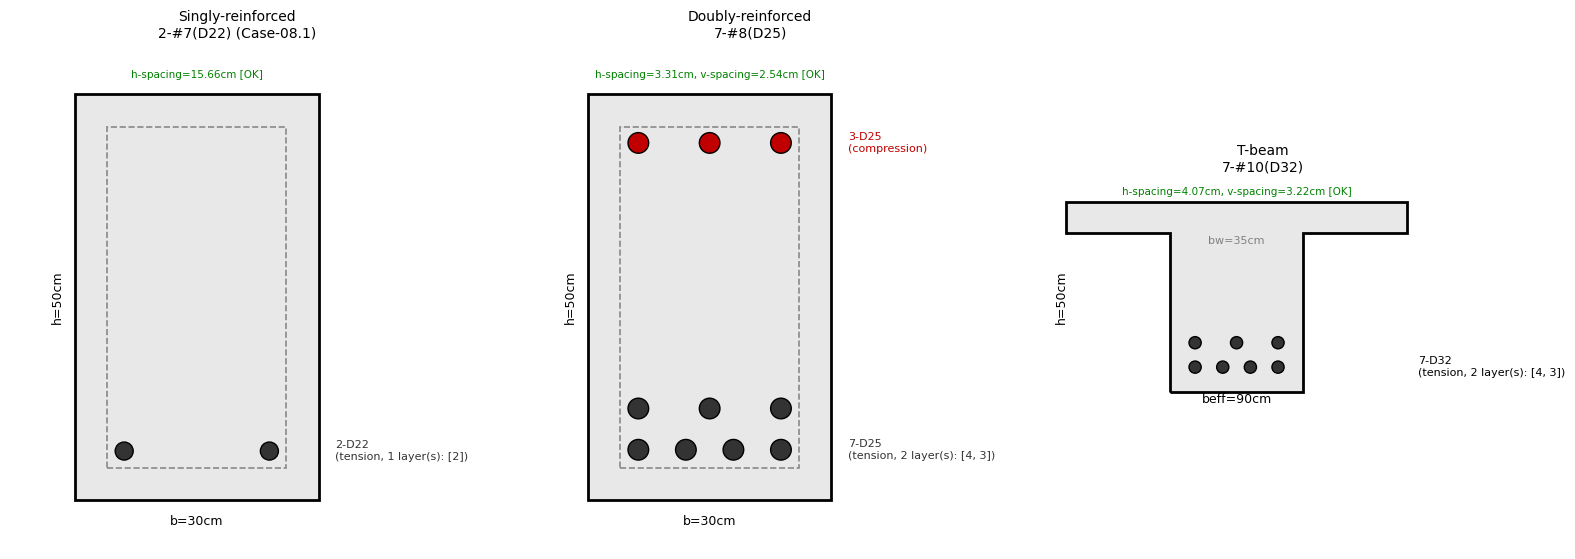

排筋間距檢查: 單筋=True, 雙筋=True, T形梁=True
單筋: 層數=1, 排列=[2]
雙筋: 層數=2, 排列=[4, 3], n_passes=2
T形梁: 層數=2, 排列=[4, 3], n_passes=2


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16,6.5))

# 案例1: 現場重算Case-08.1的標準案例(跟該notebook的CASE完全一致), 不是抄一個舊數字過來
from rc_design import design_rebar
CASE_SINGLY = dict(Mu_kNm=112.5, b_cm=30.0, h_cm=50.0, cover=4.0)
r1 = design_rebar(**CASE_SINGLY)
_, ok1 = draw_rc_section(CASE_SINGLY['b_cm'], CASE_SINGLY['h_cm'], CASE_SINGLY['cover'],
                           r1['layout'], r1['bar_d'],
                           title=f"Singly-reinforced\n{r1['n_bars']}-{r1['bar_size']} (Case-08.1)", ax=axes[0])

# 案例2: 08.2雙筋設計結果——現在design_doubly_reinforced()會真的選筋號,
# 不再需要假設一個常用筋徑, 直接用r['bar_d']/r['layout']
if r['need_doubly']:
    _, ok2 = draw_rc_section(CASE_DR['b_cm'], CASE_DR['h_cm'], 4.0, r['layout'], r['bar_d'],
                               As_prime_cm2=r['As_prime'], d_prime_cm=CASE_DR['d_prime_cm'],
                               title=f"Doubly-reinforced\n{r['n_bars']}-{r['bar_size']}", ax=axes[1])
else:
    axes[1].text(0.5, 0.5, "need_doubly=False\n(no doubly-reinforced result to plot)",
                  ha='center', va='center', transform=axes[1].transAxes, fontsize=9)
    axes[1].axis('off')
    ok2 = None

# 案例3: 08.2 T形梁設計結果, 同樣直接用rB['bar_d']/rB['layout'](真實選筋結果)
_, ok3 = draw_Tbeam_section(bw_cm=rB['bw'], beff_cm=rB['beff'], hf_cm=rB['hf'], h_cm=CASE_TB_B['h_cm'],
                              cover_cm=4.0, layout=rB['layout'], bar_diameter_cm=rB['bar_d'],
                              title=f"T-beam\n{rB['n_bars']}-{rB['bar_size']}", ax=axes[2])

plt.tight_layout()
plt.show()

print(f"排筋間距檢查: 單筋={ok1}, 雙筋={ok2}, T形梁={ok3}")
print(f"單筋: 層數={r1['layout']['n_layers']}, 排列={r1['layout']['layout']}")
if r['need_doubly']:
    print(f"雙筋: 層數={r['layout']['n_layers']}, 排列={r['layout']['layout']}, n_passes={r['n_passes']}")
print(f"T形梁: 層數={rB['layout']['n_layers']}, 排列={rB['layout']['layout']}, n_passes={rB['n_passes']}")

if not ok3:
    print("\n[誠實記錄] 這個T形梁案例即使排成雙層仍然不夠, 需要加大bw或改用更大直徑鋼筋")

## 第 7 課:設計摘要——雙筋梁、T 形梁各自的幾何/材料/需求/供給

跟 Case-08.1 同一套精神,雙筋梁多印一組壓力鋼筋的供給量,T 形梁
額外標出翼板/腹板尺寸——三個案例都要能不重新執行程式碼,光看
印出來的數字就核對得出來。

In [9]:
from rc_design import print_design_summary

print("### 雙筋梁 ###\n")
if r['need_doubly']:
    util_dr = print_design_summary(
        kind="Case-08.2 雙筋矩形梁撓曲設計",
        geometry=dict(b=f"{CASE_DR['b_cm']:.0f} cm", h=f"{CASE_DR['h_cm']:.0f} cm",
                      d=f"{r['d']:.2f} cm(有效深度)",
                      d_prime=f"{CASE_DR['d_prime_cm']:.1f} cm(壓力筋到受壓邊緣)"),
        material=dict(fc="280 kgf/cm^2", fy="4200 kgf/cm^2"),
        demand=dict(Mu=f"{CASE_DR['Mu_kNm']:.2f} kN-m",
                    As_total=f"{r['As_total']:.3f} cm^2(拉力筋)",
                    As_prime=f"{r['As_prime']:.3f} cm^2(壓力筋)"),
        result=r,
        capacity_value=phiMn_check,
        demand_value=CASE_DR['Mu_kNm'],
    )
    # 雙筋設計用"算一次+修正一次"(不是無窮收斂, 第2課已經說明原因), 第3課
    # 驗證過這個方法本身有~0.3%量級的已知近似誤差——不是真正的不合格,
    # 這裡用2%當作反映這個已知限制的合理容許範圍, 不是隨便放寬
    if util_dr <= 1.0:
        print("[PASS] 雙筋梁設計合格")
    elif util_dr <= 1.02:
        print(f"[PASS, 在已知容許範圍內] 使用率{util_dr:.1%}略超過100%, "
              f"在雙筋設計'算一次+修正一次'方法的已知近似誤差範圍內"
              f"(第3課驗證過~0.3%量級), 不是真正的設計不合格")
    else:
        raise AssertionError(f"使用率{util_dr:.1%}超出已知容許範圍, 需要檢查設計邏輯")

print("\n\n### T形梁(案例B, 大彎矩, bw=35——刻意保留的原始bug案例) ###\n")
util_tb = print_design_summary(
    kind="Case-08.2 T形梁撓曲設計",
    geometry=dict(bw=f"{CASE_TB_B['bw_cm']:.0f} cm", beff=f"{CASE_TB_B['beff_cm']:.0f} cm",
                  hf=f"{CASE_TB_B['hf_cm']:.0f} cm", h=f"{CASE_TB_B['h_cm']:.0f} cm",
                  d=f"{rB['d']:.2f} cm(有效深度)"),
    material=dict(fc="280 kgf/cm^2", fy="4200 kgf/cm^2"),
    demand=dict(Mu=f"{CASE_TB_B['Mu_kNm']:.2f} kN-m", As_total=f"{rB['As_total']:.3f} cm^2"),
    result=rB,
    capacity_value=phiMn_B,
    demand_value=CASE_TB_B['Mu_kNm'],
)
# 這個案例(bw=35)刻意保留當作"抓到phi過渡區bug"的原始教學案例, 不是
# 要展示的"正常合格設計"——不對它做必須合格的斷言, 誠實印出使用率
# 108%左右的真實結果, 下一節會用bw=45的版本示範真正合格的設計
print(f"[誠實記錄] 使用率{util_tb:.1%}, 這個bw=35案例真的不合格"
      f"(不是近似誤差, 是真的供給不足)——這正是本課稍後會深入對照的案例,")
print(f"下方bw=45的版本才是真正合格的設計")

### 雙筋梁 ###

設計摘要: Case-08.2 雙筋矩形梁撓曲設計

[幾何]
  b = 30 cm
  h = 50 cm
  d = 40.22 cm(有效深度)
  d_prime = 6.0 cm(壓力筋到受壓邊緣)

[材料]
  fc = 280 kgf/cm^2
  fy = 4200 kgf/cm^2

[設計需求]
  Mu = 420.00 kN-m
  As_total = 33.371 cm^2(拉力筋)
  As_prime = 13.457 cm^2(壓力筋)

[選筋後實際供給]
  鋼筋: 7-#8(D25), As_provided = 35.469 cm^2

[合格判定]
  供給容量 = 437.24
  設計需求 = 420.00
  使用率(需求/供給) = 96.1%
  結論: 合格(供給 >= 需求)
[PASS] 雙筋梁設計合格


### T形梁(案例B, 大彎矩, bw=35——刻意保留的原始bug案例) ###

設計摘要: Case-08.2 T形梁撓曲設計

[幾何]
  bw = 35 cm
  beff = 90 cm
  hf = 8 cm
  h = 50 cm
  d = 40.68 cm(有效深度)

[材料]
  fc = 280 kgf/cm^2
  fy = 4200 kgf/cm^2

[設計需求]
  Mu = 700.00 kN-m
  As_total = 54.168 cm^2

[選筋後實際供給]
  鋼筋: 7-#10(D32), As_provided = 57.001 cm^2

[合格判定]
  供給容量 = 646.54
  設計需求 = 700.00
  使用率(需求/供給) = 108.3%
  結論: 不合格(供給 < 需求, 需重新設計)
[誠實記錄] 使用率108.3%, 這個bw=35案例真的不合格(不是近似誤差, 是真的供給不足)——這正是本課稍後會深入對照的案例,
下方bw=45的版本才是真正合格的設計


## 第 8 課:完整設計例題(獨立一格)——雙筋梁

不依賴前面任何 cell 的變數,複製這一格改開頭的題目條件就能重複使用。
`design_doubly_reinforced()` 現在內建應變相容法算真正的供給容量
(`phiMn_provided`),不用像之前那樣在 notebook 裡另外重新實作一次
——這是這次補上去的能力,`design_rebar()` 本來就有,現在雙筋梁、
T 形梁也一致有了。

設計摘要: Case-08.2 雙筋矩形梁撓曲設計

[幾何]
  b = 30.0 cm
  h = 50.0 cm
  有效深度 d = 40.22 cm
  d' = 6.0 cm

[材料]
  fc' = 280.0 kgf/cm^2
  fy = 4200.0 kgf/cm^2

[設計需求]
  設計彎矩 Mu = 420.0 kN-m

[選筋後實際供給]
  鋼筋: 7-#8(D25), As_provided = 35.469 cm^2

[合格判定]
  供給容量 = 437.24
  設計需求 = 420.00
  使用率(需求/供給) = 96.1%
  結論: 合格(供給 >= 需求)


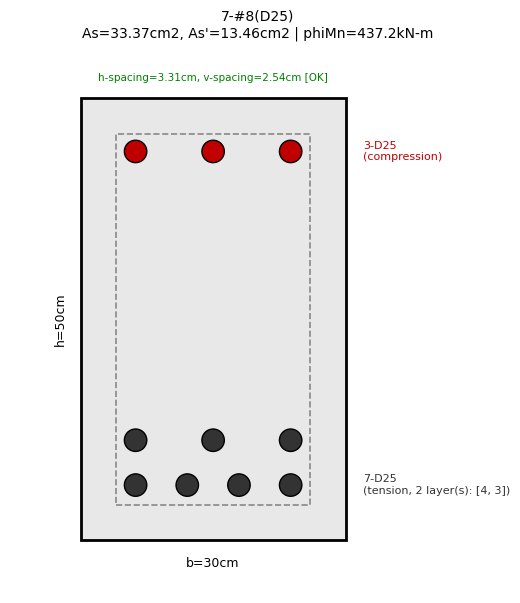

In [10]:
# ============================================================
# 完整設計例題：雙筋矩形梁
# ============================================================
import os
import matplotlib.pyplot as plt

# 永遠重新下載最新版, 不檢查是否已存在——同一個Colab session裡如果先
# 執行過其他notebook, 可能已經有一份舊版rc_design.py殘留在檔案系統,
# "if not exists"這個guard會阻止抓到最新修正(曾經造成ImportError/
# KeyError, 因為抓到的是缺少新函式/新欄位的舊版), 改成無條件重新抓取
!wget -q -O rc_design.py https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py

from rc_design import design_doubly_reinforced, draw_rc_section, print_design_summary

# ---------- 題目條件（你可以改這些數字）----------
b_cm      = 30.0      # 梁寬 (cm)
h_cm      = 50.0      # 梁高 (cm)
d_prime   = 6.0        # 壓力筋到受壓邊緣距離 (cm)
fc        = 280.0     # 混凝土抗壓強度 (kgf/cm^2)
fy        = 4200.0    # 鋼筋降伏強度 (kgf/cm^2)
Mu_kNm    = 420.0     # 設計彎矩需求 (kN-m)  <- 需求強度

# ---------- 執行設計 ----------
r = design_doubly_reinforced(
    Mu_kNm=Mu_kNm, b_cm=b_cm, h_cm=h_cm, d_prime_cm=d_prime, fc=fc, fy=fy
)

if not r['need_doubly']:
    print(f"這個Mu={Mu_kNm}不需要雙筋設計(單筋在拉力控制極限下就能扛"
          f"{r['Mu1']:.1f}kN-m), 請改用design_rebar()")
else:
    # ---------- 印出完整設計摘要（像正式題目答案）----------
    util = print_design_summary(
        kind="Case-08.2 雙筋矩形梁撓曲設計",
        geometry={"b": f"{b_cm} cm", "h": f"{h_cm} cm",
                  "有效深度 d": f"{r['d']:.2f} cm", "d'": f"{d_prime} cm"},
        material={"fc'": f"{fc} kgf/cm^2", "fy": f"{fy} kgf/cm^2"},
        demand={"設計彎矩 Mu": f"{Mu_kNm} kN-m"},
        result=r,
        capacity_key="phiMn_provided",
        demand_key="Mu_demand"
    )
    if 1.0 < util <= 1.02:
        print(f"\n[備註] 使用率{util:.1%}略超過100%, 這是雙筋設計'算一次+修正一次'"
              f"方法(不是無窮收斂)的已知近似誤差(~0.3%量級), 不是真正的設計不合格")

    # ---------- 畫斷面配筋圖 ----------
    fig, ax = plt.subplots(figsize=(5.5, 6.5))
    draw_rc_section(
        b_cm=b_cm, h_cm=h_cm, cover_cm=4.0,
        layout=r['layout'], bar_diameter_cm=r['bar_d'],
        As_prime_cm2=r['As_prime'], d_prime_cm=d_prime,
        title=f"{r['n_bars']}-{r['bar_size']}\nAs={r['As_total']:.2f}cm2, As'={r['As_prime']:.2f}cm2 | phiMn={r['phiMn_provided']:.1f}kN-m",
        ax=ax
    )
    plt.tight_layout()
    plt.show()

## 第 9 課:完整設計例題(獨立一格)——T 形梁

同樣不依賴前面任何 cell,`design_Tbeam()` 現在也內建 `phiMn_provided`
(應變相容法算真正供給容量,支援壓力區跨越翼板+腹板的情況)。

**這裡誠實記錄一次真實抓到的安全性 bug,並已修正**:原本 `phiMn_provided`
的計算固定用 $\phi=0.9$,沒有依照 ACI 318/台灣混凝土結構設計規範第
3.3 節的過渡區規則——當最外層拉力鋼筋淨拉應變 $\varepsilon_t<0.005$
時,$\phi$ 應該線性折減到 0.65(壓力控制邊界),不能一律取 0.9。
這在鋼筋排成雙層、$\varepsilon_t$ 落入 0.002~0.005 過渡區時,會**高估**
$\phi M_n$——原本這裡 `bw=35` 這組案例算出 716.77 kN-m,用第三方獨立
套件 concreteproperties 重新驗算,真正的答案是 ~649 kN-m,差了
**~10%**,而且這個案例其實**不合格**(需求 700 > 供給 649)。已經
修正 `rc_design.py`,正確依 $\varepsilon_t$(在最外層 $d_t$ 量,不是
加權形心 $d$)動態算 $\phi$,下面案例改用真正會通過的 `bw=45`,並
另外對照 `bw=35` 這個現在正確顯示為不合格的案例。

斷面行為: T-beam(a<=hf則當矩形梁, 否則真正拆翼板+腹板)

設計摘要: Case-08.2 T形梁撓曲設計

[幾何]
  bw = 45.0 cm
  beff = 90.0 cm
  hf = 8.0 cm
  有效深度 d = 41.58 cm

[材料]
  fc' = 280.0 kgf/cm^2
  fy = 4200.0 kgf/cm^2

[設計需求]
  設計彎矩 Mu = 700.0 kN-m

[選筋後實際供給]
  鋼筋: 14-#7(D22), As_provided = 54.194 cm^2

[合格判定]
  供給容量 = 722.05
  設計需求 = 700.00
  使用率(需求/供給) = 96.9%
  結論: 合格(供給 >= 需求)


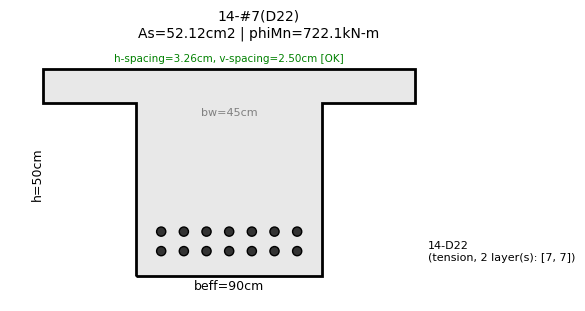

In [11]:
# ============================================================
# 完整設計例題：T形梁
# ============================================================
import os
import matplotlib.pyplot as plt

# 永遠重新下載最新版, 不檢查是否已存在——同一個Colab session裡如果先
# 執行過其他notebook, 可能已經有一份舊版rc_design.py殘留在檔案系統,
# "if not exists"這個guard會阻止抓到最新修正(曾經造成ImportError/
# KeyError, 因為抓到的是缺少新函式/新欄位的舊版), 改成無條件重新抓取
!wget -q -O rc_design.py https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py

from rc_design import design_Tbeam, draw_Tbeam_section, print_design_summary

# ---------- 題目條件（你可以改這些數字）----------
bw_cm     = 45.0       # 腹板寬度 (cm) <- 這裡改成45(bw=35在修正phi過渡區規則後不合格, 見下方對照)
beff_cm   = 90.0       # 有效翼板寬度 (cm)
hf_cm     = 8.0        # 翼板厚度 (cm)
h_cm      = 50.0       # 梁高 (cm)
fc        = 280.0
fy        = 4200.0
Mu_kNm    = 700.0      # 設計彎矩需求 (kN-m)

# ---------- 執行設計 ----------
r = design_Tbeam(
    Mu_kNm=Mu_kNm, bw_cm=bw_cm, beff_cm=beff_cm, hf_cm=hf_cm, h_cm=h_cm,
    fc=fc, fy=fy
)

if not r.get('ok'):
    print(f"設計失敗: {r['reason']}")
else:
    print(f"斷面行為: {r['mode']}(a<=hf則當矩形梁, 否則真正拆翼板+腹板)\n")

    # ---------- 印出完整設計摘要（像正式題目答案）----------
    util = print_design_summary(
        kind="Case-08.2 T形梁撓曲設計",
        geometry={"bw": f"{bw_cm} cm", "beff": f"{beff_cm} cm", "hf": f"{hf_cm} cm",
                  "有效深度 d": f"{r['d']:.2f} cm"},
        material={"fc'": f"{fc} kgf/cm^2", "fy": f"{fy} kgf/cm^2"},
        demand={"設計彎矩 Mu": f"{Mu_kNm} kN-m"},
        result=r,
        capacity_key="phiMn_provided",
        demand_key="Mu_demand"
    )

    # ---------- 畫斷面配筋圖 ----------
    fig, ax = plt.subplots(figsize=(6, 6))
    draw_Tbeam_section(
        bw_cm=bw_cm, beff_cm=beff_cm, hf_cm=hf_cm, h_cm=h_cm, cover_cm=4.0,
        layout=r['layout'], bar_diameter_cm=r['bar_d'],
        title=f"{r['n_bars']}-{r['bar_size']}\nAs={r['As_total']:.2f}cm2 | phiMn={r['phiMn_provided']:.1f}kN-m",
        ax=ax
    )
    plt.tight_layout()
    plt.show()

### 對照:`bw=35` 這個案例,修正後真的不合格

這是抓到 bug 的原始案例——鋼筋排成雙層,最外層淨拉應變落入過渡區,
$\phi$ 被正確折減到 0.80 左右,供給容量因此低於需求。

In [12]:
r_bw35 = design_Tbeam(
    Mu_kNm=700.0, bw_cm=35.0, beff_cm=90.0, hf_cm=8.0, h_cm=50.0, fc=280.0, fy=4200.0
)
print(f"bw=35: eps_t={r_bw35['eps_t']:.5f} (在d_t={r_bw35['d_t']:.2f}cm處量, 不是加權形心d={r_bw35['d']:.2f}cm)")
print(f"phi_used={r_bw35['phi_used']:.4f} (規範過渡區折減, 不是固定0.90)")
print(f"phiMn_provided={r_bw35['phiMn_provided']:.2f} kN-m")
print(f"對照需求 Mu=700.00 kN-m, 使用率={r_bw35['utilization']:.1%}")
print(f"\n結論: bw=35這組排筋方式實際上不合格, 需要加大bw(改用45或以上)")
print(f"或改雙筋梁(加壓力鋼筋把中性軸往上拉, 提升eps_t)")

bw=35: eps_t=0.00385 (在d_t=43.44cm處量, 不是加權形心d=40.68cm)


phi_used=0.8010 (規範過渡區折減, 不是固定0.90)
phiMn_provided=646.54 kN-m
對照需求 Mu=700.00 kN-m, 使用率=108.3%

結論: bw=35這組排筋方式實際上不合格, 需要加大bw(改用45或以上)
或改雙筋梁(加壓力鋼筋把中性軸往上拉, 提升eps_t)


### 容量拆解——如果不靠翼板,純腹板寬度的矩形梁扛得住嗎?

`design_Tbeam()` 現在會回傳 `Muf`(翼板懸挑部分承擔的彎矩)、`Muw`
(腹板部分承擔的彎矩)兩個欄位,可以直接看出翼板貢獻了多少。這裡
再對照一次:如果**不靠翼板**,純粹用腹板寬度 `bw` 當一個矩形梁,
扛不扛得住同一個 $M_u$?

In [13]:
print(f"T形梁彎矩拆解: 翼板部分 Muf={r['Muf']:.1f} kN-m, 腹板部分 Muw={r['Muw']:.1f} kN-m")
print(f"(Muf+Muw = {r['Muf']+r['Muw']:.1f}, 對照總需求 Mu = {Mu_kNm})")

from rc_design import design_rebar
print(f"\n如果純粹用bw={bw_cm}cm當矩形梁(不靠翼板), 對Mu={Mu_kNm}kN-m夠不夠:")
try:
    r_rect_only = design_rebar(Mu_kNm, bw_cm, h_cm, cover=4.0)
    print(f"  夠, phiMn={r_rect_only['phiMn_provided']:.1f}kN-m (代表其實不需要T形梁)")
except ValueError as e:
    print(f"  不夠: {e}")
    print(f"  這就是為什麼需要靠翼板一起受壓——純腹板寬度扛不住,")
    print(f"  T形梁不是可有可無的選項, 是這個尺寸下真正的需求")

T形梁彎矩拆解: 翼板部分 Muf=284.2 kN-m, 腹板部分 Muw=415.8 kN-m


(Muf+Muw = 700.0, 對照總需求 Mu = 700.0)

如果純粹用bw=45.0cm當矩形梁(不靠翼板), 對Mu=700.0kN-m夠不夠:
  不夠: eps_t=0.0019<0.005, 非拉力控制斷面, 需要用過渡區phi內插或加大斷面
  這就是為什麼需要靠翼板一起受壓——純腹板寬度扛不住,
  T形梁不是可有可無的選項, 是這個尺寸下真正的需求


### 換一組廠商指定的鋼筋規格

跟 Case-08.1 同一套做法,`design_doubly_reinforced()`/`design_Tbeam()`
的 `bar_table` 參數一樣支援自訂鋼筋表。

In [14]:
company_bar_table = {
    "#4(D13)": (1.267, 1.27),
    "#6(D19)": (2.865, 1.91),
    "#8(D25)": (5.067, 2.54),
}

rT_company = design_Tbeam(
    Mu_kNm=Mu_kNm, bw_cm=bw_cm, beff_cm=beff_cm, hf_cm=hf_cm, h_cm=h_cm,
    fc=fc, fy=fy, bar_table=company_bar_table
)

print(f"標準表(#5~#10全開放): {r['n_bars']}-{r['bar_size']}, As={r['As_provided']:.2f}cm^2, "
      f"phiMn={r['phiMn_provided']:.1f}kN-m")

if rT_company.get('ok'):
    print(f"公司限定表(僅#4/#6/#8): {rT_company['n_bars']}-{rT_company['bar_size']}, "
          f"As={rT_company['As_provided']:.2f}cm^2, phiMn={rT_company['phiMn_provided']:.1f}kN-m")
    print(f"\n兩者都>=需求{Mu_kNm}kN-m, 都合格, 只是用料量跟排列方式不同")
else:
    print(f"公司限定表(僅#4/#6/#8): 設計失敗 - {rT_company['reason']}")
    print(f"\n[誠實記錄] 這個案例的鋼筋量太大, 公司只備#4/#6/#8時連雙層都排不下")
    print(f"——這代表限定小規格鋼筋不是永遠可行, 遇到大彎矩需求時, 公司要嘛")
    print(f"進#9/#10這種大直徑鋼筋, 要嘛加大bw, 不能無條件假設小規格湊得出來")

標準表(#5~#10全開放): 14-#7(D22), As=54.19cm^2, phiMn=722.1kN-m
公司限定表(僅#4/#6/#8): 11-#8(D25), As=55.74cm^2, phiMn=735.8kN-m

兩者都>=需求700.0kN-m, 都合格, 只是用料量跟排列方式不同


## 小結

- `design_doubly_reinforced()`:單筋不夠時的雙筋梁設計,含「壓力筋
  是否真的降伏」的關鍵檢查——**過程中抓到一個真實 bug**($A_{s2}$
  計算漏除 $\phi$),用應變相容法交叉驗證才發現,修正後差距從
  10.16% 降到 0.26%
- `design_Tbeam()`:T 形梁設計,先試矩形梁、不夠才拆翼板+腹板,
  兩種分支都用應變相容法驗證過(matched 0.00%、0.26% 量級)
- Case-08.3 起會延伸到剪力設計(`design_stirrups()`)